In [1]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

# Data load

## xenopus prots

In [2]:
DATA_DIR = "/n/groups/kirschner/xenopus/ms/xenopus"

prots_mf = pd.read_csv(os.path.join(DATA_DIR, "all_organs_15124_proteins_12_15_23_w_gender_annotate.csv"))
prots_xen = pd.read_csv(os.path.join(DATA_DIR, "all_organs_14986_proteins_unique_pep_only_12_15_23.csv"))
prots_xen.columns = prots_mf.columns
prots_xen.drop("muscle_leg_h_male", axis=1, inplace=True)

prots_xen[["gene_id", "gene_name"]] = prots_xen.gene_symbol.str.split("_", n=1, expand=True)

prots_xen["name_id"] = prots_xen.gene_name.astype("str") + "_" + prots_xen.gene_id
prots_xen.loc[prots_xen.gene_name.isna(), "name_id"] = prots_xen.gene_id

xen_organs = prots_xen.columns[1: -3]

prots_xen["fake"] = prots_xen.gene_symbol.str.startswith("##")
prots_xen["contaminant"] = prots_xen.gene_symbol.str.contains("contaminant")

# delete ## and contaminants genes
prots_xen = prots_xen.loc[~(prots_xen["fake"] | prots_xen["contaminant"]),:]

prots_xen = prots_xen.replace(np.inf, np.nan)

total = pd.DataFrame(prots_xen[xen_organs].replace(np.nan, 0).sum(axis=0))
total.columns = ["total", ]
total["organ"] = None

total["added"] = total.index.str.match(r"f\d")

total.loc[total.added, "organ"] = \
    total.index.to_series().loc[total.added].str.split("_", n=1, expand=True).iloc[:,1].str.rsplit("_", n=1, expand=True).iloc[:,0]

total.loc[~total.added, "organ"] = total.index.to_series().loc[~total.added].str.rsplit("_", n=2, expand=True).iloc[:,0]

total["sex"] = total.index.to_series().str.rsplit("_", n=1, expand=True).iloc[:,-1]

total.loc[total.organ == "bladder", "organ"] = "urinary_bladder"
total.loc[total.organ == "eye", "organ"] = "whole_eye"
total.loc[total.organ == "rem_brain", "organ"] = "brain"
total.loc[total.organ == "tele", "organ"] = "telencephalon"
total.loc[total.organ == "pns", "organ"] = "PNS"
total.loc[total.organ == "marrow", "organ"] = "bone_marrow"

In [3]:
prots_xen_set = set(prots_xen.gene_id)

In [4]:
prots_xen_names = set(prots_xen.gene_name)

In [5]:
prots_xen

,gene_symbol,thymus_a_female,spleen_a_female,stomach_a_female,lungs_a_female,heart_vent_a_female,liver_a_female,larynx_a_female,intestine_a_female,kidney_a_female,...,f17_rem_brain_male,f2_pns_female,f4_eye_female,f8_eye_male,f10_eye_male,gene_id,gene_name,name_id,fake,contaminant
45,Q5G7H8_CYTB,0.321371,0.463052,1.569102,0.143623,3.496611,0.790063,0.662055,0.490875,1.225277,...,2.070206,0.859807,0.685964,0.655302,0.774498,Q5G7H8,CYTB,CYTB_Q5G7H8,False,False
46,Q5G7I0_ND5,0.448964,0.318231,1.072837,0.261576,3.680017,0.542338,1.080215,0.660867,1.170661,...,1.782446,0.371906,0.646819,0.776143,0.704451,Q5G7I0,ND5,ND5_Q5G7I0,False,False
47,Q5G7I1_ND4,0.427431,0.213992,1.348631,0.126246,6.405133,0.489845,0.777605,0.733844,2.040823,...,2.949203,0.978983,0.641257,0.771072,0.764097,Q5G7I1,ND4,ND4_Q5G7I1,False,False
48,Q5G7I4_COX3,1.035688,0.331578,1.665234,0.549595,4.360334,0.442933,1.517364,0.976960,2.141383,...,NaN,NaN,NaN,NaN,NaN,Q5G7I4,COX3,COX3_Q5G7I4,False,False
49,Q5G7I7_COX2,0.520534,0.247378,1.153810,0.256141,3.482945,0.722318,0.895752,0.736343,1.307359,...,1.376034,0.251602,0.456572,0.603719,0.519685,Q5G7I7,COX2,COX2_Q5G7I7,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14981,Xetrov107057049m_LTK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.341500,1.370082,2.835495,2.694506,3.539462,Xetrov107057049m,LTK,LTK_Xetrov107057049m,False,False
14982,Xetrov107058372m_CD84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.253541,0.882767,1.191948,1.736674,1.278815,Xetrov107058372m,CD84,CD84_Xetrov107058372m,False,False
14983,Xetrov107059498m_ZNF224,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.035222,0.790697,1.788745,1.190012,1.253251,Xetrov107059498m,ZNF224,ZNF224_Xetrov107059498m,False,False
14984,Xetrov107060283m_HYLS1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.841800,0.493263,0.658752,0.779288,0.672007,Xetrov107060283m,HYLS1,HYLS1_Xetrov107060283m,False,False


## unipot

In [6]:
REF_DIR = "/n/groups/kirschner/xenopus/reference"
uni_human_prots = pd.read_csv(os.path.join(REF_DIR, "Homo.fa.defs.tsv"), sep="\t", header=None)
uni_human_prots["uniprot_id"] = uni_human_prots.iloc[:,0].str.split("|", expand=True)[1]
uni_human_prots

,0,1,2,3,uniprot_id
0,tr|A0A024R1R8|A0A024R1R8_HUMAN,hCG_2014768,"HCG2014768, isoform CRA_a",Homo sapiens,A0A024R1R8
1,sp|A0A024RBG1|NUD4B_HUMAN,NUDT4B,Diphosphoinositol polyphosphate phosphohydrola...,Homo sapiens,A0A024RBG1
2,tr|A0A075B6H5|A0A075B6H5_HUMAN,TRBV20OR9-2,T cell receptor beta variable 20/OR9-2 (non-fu...,Homo sapiens,A0A075B6H5
3,tr|A0A075B6H7|A0A075B6H7_HUMAN,IGKV3-7,Immunoglobulin kappa variable 3-7 (non-functio...,Homo sapiens,A0A075B6H7
4,tr|A0A075B6H8|A0A075B6H8_HUMAN,IGKV1D-42,Immunoglobulin kappa variable 1D-42 (non-funct...,Homo sapiens,A0A075B6H8
...,...,...,...,...,...
20143,sp|Q9Y6Z7|COL10_HUMAN,COLEC10,Collectin-10,Homo sapiens,Q9Y6Z7
20144,sp|S4R3P1|HMN13_HUMAN,MTRNR2L13,Humanin-like 13,Homo sapiens,S4R3P1
20145,sp|S4R3Y5|HMN11_HUMAN,MTRNR2L11,Humanin-like 11,Homo sapiens,S4R3Y5
20146,sp|U3KPV4|A3LT2_HUMAN,A3GALT2,"Alpha-1,3-galactosyltransferase 2",Homo sapiens,U3KPV4


In [7]:
uni_human_prots.iloc[:,1].value_counts()

1
HERVK_113      5
TJP2           2
HERV-K104      2
ZNF280D        2
hCG_2014768    1
              ..
YWHAE          1
UBE2H          1
UBE2G1         1
RPS16          1
SPACA6         1
Name: count, Length: 20141, dtype: int64

In [8]:
REF_DIR = "/n/groups/kirschner/xenopus/ms/reference"
xen2human = pd.read_csv(os.path.join(REF_DIR, "Xtr10mtDB_mapped_to_human_GS_leon_server.tsv"), sep="\t")
xen2human["uniprot_id"] = xen2human.iloc[:,1].str.split("|", expand=True).iloc[:,1]
xen2human

,trop_protein_id,mapped_human_uniprot_id,mapped_human_gene_symbol,description,e_value_1,e_value_2,uniprot_id
0,Q5G7H8_CYTB,sp|P00156|CYB_HUMAN,MT-CYB,Cytochrome b,9.300000e-194,9.300000e-194,P00156
1,Q5G7H9_ND6,sp|P03923|NU6M_HUMAN,MT-ND6,NADH-ubiquinone oxidoreductase chain 6,1.900000e-25,7.100000e-26,P03923
2,Q5G7I0_ND5,sp|P03915|NU5M_HUMAN,MT-ND5,NADH-ubiquinone oxidoreductase chain 5,1.300000e-218,2.500000e-218,P03915
3,Q5G7I1_ND4,sp|P03905|NU4M_HUMAN,MT-ND4,NADH-ubiquinone oxidoreductase chain 4,1.300000e-181,7.500000e-182,P03905
4,Q5G7I2_ND4L,sp|P03901|NU4LM_HUMAN,MT-ND4L,NADH-ubiquinone oxidoreductase chain 4L,1.600000e-24,4.600000e-24,P03901
...,...,...,...,...,...,...,...
20480,Xetrov107063496m_PNPLA7,sp|Q6ZV29|PLPL7_HUMAN,PNPLA7,Patatin-like phospholipase domain-containing p...,2.900000e-54,NaN,Q6ZV29
20481,Xetrov107063498m_SLC25A34,sp|Q6PIV7|S2534_HUMAN,SLC25A34,Solute carrier family 25 member 34,6.600000e-74,1.100000e-77,Q6PIV7
20482,Xetrov107063502m_RAP1GAP,sp|P47736|RPGP1_HUMAN,RAP1GAP,Rap1 GTPase-activating protein 1,1.300000e-47,NaN,P47736
20483,Xetrov107063503m_SLC31A1,sp|O15431|COPT1_HUMAN,SLC31A1,High affinity copper uptake protein 1,1.300000e-73,3.500000e-74,O15431


In [9]:
xen2human["xenopus_gene_id"] = xen2human.trop_protein_id.str.split("_", expand=True).iloc[:,0]
xen2uniprot = xen2human.set_index("xenopus_gene_id")

In [10]:
prots_xen["uniprot_id"] = None
idx = prots_xen.gene_symbol.isin(xen2human.trop_protein_id)
prots_xen.loc[idx, "uniprot_id"] = xen2human.set_index("trop_protein_id").loc[prots_xen.loc[idx, "gene_symbol"], "uniprot_id"].values
prots_xen

,gene_symbol,thymus_a_female,spleen_a_female,stomach_a_female,lungs_a_female,heart_vent_a_female,liver_a_female,larynx_a_female,intestine_a_female,kidney_a_female,...,f2_pns_female,f4_eye_female,f8_eye_male,f10_eye_male,gene_id,gene_name,name_id,fake,contaminant,uniprot_id
45,Q5G7H8_CYTB,0.321371,0.463052,1.569102,0.143623,3.496611,0.790063,0.662055,0.490875,1.225277,...,0.859807,0.685964,0.655302,0.774498,Q5G7H8,CYTB,CYTB_Q5G7H8,False,False,P00156
46,Q5G7I0_ND5,0.448964,0.318231,1.072837,0.261576,3.680017,0.542338,1.080215,0.660867,1.170661,...,0.371906,0.646819,0.776143,0.704451,Q5G7I0,ND5,ND5_Q5G7I0,False,False,P03915
47,Q5G7I1_ND4,0.427431,0.213992,1.348631,0.126246,6.405133,0.489845,0.777605,0.733844,2.040823,...,0.978983,0.641257,0.771072,0.764097,Q5G7I1,ND4,ND4_Q5G7I1,False,False,P03905
48,Q5G7I4_COX3,1.035688,0.331578,1.665234,0.549595,4.360334,0.442933,1.517364,0.976960,2.141383,...,NaN,NaN,NaN,NaN,Q5G7I4,COX3,COX3_Q5G7I4,False,False,P00414
49,Q5G7I7_COX2,0.520534,0.247378,1.153810,0.256141,3.482945,0.722318,0.895752,0.736343,1.307359,...,0.251602,0.456572,0.603719,0.519685,Q5G7I7,COX2,COX2_Q5G7I7,False,False,P00403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14981,Xetrov107057049m_LTK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.370082,2.835495,2.694506,3.539462,Xetrov107057049m,LTK,LTK_Xetrov107057049m,False,False,P29376
14982,Xetrov107058372m_CD84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.882767,1.191948,1.736674,1.278815,Xetrov107058372m,CD84,CD84_Xetrov107058372m,False,False,Q9UIB8
14983,Xetrov107059498m_ZNF224,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.790697,1.788745,1.190012,1.253251,Xetrov107059498m,ZNF224,ZNF224_Xetrov107059498m,False,False,Q9NZL3
14984,Xetrov107060283m_HYLS1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.493263,0.658752,0.779288,0.672007,Xetrov107060283m,HYLS1,HYLS1_Xetrov107060283m,False,False,Q96M11


## human prots

In [11]:
from Bio import SeqIO


REF_DIR = "/n/groups/kirschner/xenopus/ms/reference/human"

fasta_fp = os.path.join(REF_DIR, "gencode.v19.pc_translations.longest.fa")
human_genes = []

with open(fasta_fp) as handle:
    for record in SeqIO.parse(handle, "fasta"):
        splits = record.id.split("|")
        gene_id = splits[1].split(".")[0]
        gene_name = splits[5]
        human_genes.append(
            {
                "human_gene_id": gene_id,
                "human_gene_name": gene_name
            }
        )
human_genes_df = pd.DataFrame.from_dict(human_genes)        
        
HUMAN_DIR = "/n/groups/kirschner/xenopus/ms/human"
prots_human = pd.read_csv(os.path.join(HUMAN_DIR, "1-s2.0-S0092867420310783-mmc3.csv"), header=None)
prots_human.iloc[2:,0] = prots_human.iloc[2:,0].str.split(".", expand=True).iloc[:,0].copy()
prots_human.set_index(0, inplace=True, drop=True)
prots_human.columns = prots_human.loc["sample",:]
prots_human.drop("sample", axis=0, inplace=True)

REF_DIR = "/n/groups/kirschner/xenopus/ms/reference/human"
ens2uni_filtered = pd.read_csv(os.path.join(REF_DIR, "idmapping_2024_07_03.filtered.tsv"), sep="\t")

idx = human_genes_df.human_gene_id.isin(ens2uni_filtered.From)
cols = ["human_uniprot_id", "human_uniprot_name", "human_uniprot_protein_names", "human_uniprot_gene_names"]
human_genes_df.loc[idx, cols] = ens2uni_filtered.set_index("From").loc[human_genes_df.human_gene_id.loc[idx], ["Entry", "Entry Name", "Protein names", "Gene Names"]].values
human_genes_df["human_found"] = False
human_genes_df.loc[human_genes_df.human_gene_id.isin(prots_human.index), "human_found"] = True
human_genes_df.human_found.value_counts()

/tmp/ipykernel_2693/1237578551.py:23: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201) have mixed types. Specify dtype option on import or set low_memory=False.
  prots_human = pd.read_csv(os.path.join(HUMAN_DIR, "1-s2.0-S0092867420310783-mmc3.csv"), header=None)


human_found
True     12627
False     8111
Name: count, dtype: int64

In [12]:
human_genes_df.human_uniprot_id.isna().sum()

1728

## Gene sets

In [13]:
GENE_SET_DIR = "/n/groups/kirschner/xenopus/ms/reference/geneset"
gene_set_fp = os.path.join(GENE_SET_DIR, "all_gene_sets.csv")

all_gene_sets = pd.read_csv(gene_set_fp)
all_gene_sets

,name,uniprot_id,description,match,source,gene_set,beautiful_name
0,CDC7,O00311,Cell division cycle 7-related protein kinase,uniprot,gene_sets_Leon,CellCycle,CellCycle
1,UBE2C,O00762,Ubiquitin-conjugating enzyme E2 C,uniprot,gene_sets_Leon,CellCycle,CellCycle
2,CHEK1,O14757,Serine/threonine-protein kinase Chk1,uniprot,gene_sets_Leon,CellCycle,CellCycle
3,AURKA,O14965,Aurora kinase A,uniprot,gene_sets_Leon,CellCycle,CellCycle
4,BUB1,O43683,Mitotic checkpoint serine/threonine-protein ki...,uniprot,gene_sets_Leon,CellCycle,CellCycle
...,...,...,...,...,...,...,...
10092,LRP1,Q07954,Prolow-density lipoprotein receptor-related pr...,uniprot,Matt_organellas,plasma_membrane_important_gene_symbols_v2,Plasma membrane
10093,KCNH2,Q12809,Potassium voltage-gated channel subfamily H me...,uniprot,Matt_organellas,plasma_membrane_important_gene_symbols_v2,Plasma membrane
10094,OCLN,Q16625,Occludin,uniprot,Matt_organellas,plasma_membrane_important_gene_symbols_v2,Plasma membrane
10095,SCARB1,Q8WTV0,Scavenger receptor class B member 1,uniprot,Matt_organellas,plasma_membrane_important_gene_symbols_v2,Plasma membrane


In [14]:
all_gene_sets_short = all_gene_sets.drop_duplicates(["beautiful_name", "uniprot_id"], keep="first")
all_gene_sets_short

,name,uniprot_id,description,match,source,gene_set,beautiful_name
0,CDC7,O00311,Cell division cycle 7-related protein kinase,uniprot,gene_sets_Leon,CellCycle,CellCycle
1,UBE2C,O00762,Ubiquitin-conjugating enzyme E2 C,uniprot,gene_sets_Leon,CellCycle,CellCycle
2,CHEK1,O14757,Serine/threonine-protein kinase Chk1,uniprot,gene_sets_Leon,CellCycle,CellCycle
3,AURKA,O14965,Aurora kinase A,uniprot,gene_sets_Leon,CellCycle,CellCycle
4,BUB1,O43683,Mitotic checkpoint serine/threonine-protein ki...,uniprot,gene_sets_Leon,CellCycle,CellCycle
...,...,...,...,...,...,...,...
10092,LRP1,Q07954,Prolow-density lipoprotein receptor-related pr...,uniprot,Matt_organellas,plasma_membrane_important_gene_symbols_v2,Plasma membrane
10093,KCNH2,Q12809,Potassium voltage-gated channel subfamily H me...,uniprot,Matt_organellas,plasma_membrane_important_gene_symbols_v2,Plasma membrane
10094,OCLN,Q16625,Occludin,uniprot,Matt_organellas,plasma_membrane_important_gene_symbols_v2,Plasma membrane
10095,SCARB1,Q8WTV0,Scavenger receptor class B member 1,uniprot,Matt_organellas,plasma_membrane_important_gene_symbols_v2,Plasma membrane


## xenopus vs human

In [15]:
DATA_DIR = "/n/groups/kirschner/xenopus/ms/data"
XEN_VS_HUMAN_DIR = os.path.join(DATA_DIR, "xenopus_vs_human")

out_fp = os.path.join(XEN_VS_HUMAN_DIR, "xenopus_and_human_found.csv")
xenopus_and_human_found = pd.read_csv(out_fp, sep="\t")

out_fp = os.path.join(XEN_VS_HUMAN_DIR, "not_xenopus_but_human_found.csv")
not_xenopus_but_human_found = pd.read_csv(out_fp, sep="\t")

out_fp = os.path.join(XEN_VS_HUMAN_DIR, "not_human_but_xenopus_found.csv")
not_human_but_xenopus_found = pd.read_csv(out_fp, sep="\t")

out_fp = os.path.join(XEN_VS_HUMAN_DIR, "not_xenopus_not_human_found.csv")
not_xenopus_not_human_found = pd.read_csv(out_fp, sep="\t")

out_fp = os.path.join(XEN_VS_HUMAN_DIR, "pure_not_human_but_xenopus_found.csv")
pure_not_human_but_xenopus_found = pd.read_csv(out_fp, sep="\t")

out_fp = os.path.join(XEN_VS_HUMAN_DIR, "common_proteins.csv")
common_proteins = pd.read_csv(out_fp, sep="\t")

out_fp = os.path.join(XEN_VS_HUMAN_DIR, "human_specific_proteins.csv")
human_specific_proteins = pd.read_csv(out_fp, sep="\t")

out_fp = os.path.join(XEN_VS_HUMAN_DIR, "xenopus_specific_proteins.csv")
xenopus_specific_proteins = pd.read_csv(out_fp, sep="\t")

## protein vs RNA

In [16]:
PROT_RNA_DIR = os.path.join(DATA_DIR, "rna_protein_cor")
inp_fp = os.path.join(PROT_RNA_DIR, "rna_prot_gene_cor_coef.csv")

rna_prot_gene_cor_coef_df = pd.read_csv(inp_fp)
rna_prot_gene_cor_coef_df = rna_prot_gene_cor_coef_df.loc[~rna_prot_gene_cor_coef_df.Spearman_r.isna(),:]
rna_prot_gene_cor_coef_df

,Spearman_r,gene_prot,gene_rna
0,0.405594,Xetrov107030192m,Xelaev18024843m
1,0.192645,Xetrov107030211m,Xelaev18024857m
2,0.454545,Xetrov107030280m,Xelaev18024866m
3,-0.209790,Xetrov107030287m,Xelaev18024869m
4,0.699301,Xetrov107030338m,Xelaev18024883m
...,...,...,...
14058,0.321678,Xetrov107027943m,Xelaev18024583m
14059,0.706294,Xetrov107027940m,Xelaev18024586m
14060,-0.122592,Xetrov107022569m,Xelaev18024589m
14061,0.392232,Xetrov107027933m,Xelaev18024590m


## organ specific

In [17]:
import tqdm

In [18]:
DATA_DIR = "/n/groups/kirschner/xenopus/ms/xenopus"
ORGAN_SPECIFIC_DIR = os.path.join(DATA_DIR, "chi_square_organ_specificity_z")


chi_square_organ_specificity_z = {}


for organ_specific_fp in tqdm.tqdm(glob.glob(os.path.join(ORGAN_SPECIFIC_DIR, "*.txt"))):
    organs = tuple(os.path.basename(organ_specific_fp).split(".")[:-1])
    
    # print(organs, end="\r")
    
    with open(organ_specific_fp) as f:
        genes = f.read().split("\n")
        
    chi_square_organ_specificity_z[organs] = [gene.split("_")[0] for gene in genes]

100%|██████████| 2343/2343 [00:09<00:00, 242.95it/s]


In [58]:
chi_square_os_z_list = []

for organ_set, genes in chi_square_organ_specificity_z.items():
    gene_set = ".".join(organ_set)
    for gene in genes:
        if gene in xen2uniprot.index:
            uniprot_id = xen2uniprot.loc[gene, "uniprot_id"]
        else:
            uniprot_id = None
        chi_square_os_z_list.append(
            {
                "gene_set": gene_set,
                "xenopus_gene_id": gene,
                "xenopus_uniprot_id": uniprot_id,
                "source": "chi_square_organ_specificity_z"
            }
        )
        
chi_square_os_z = pd.DataFrame(chi_square_os_z_list)

In [20]:
ORGAN_SPECIFIC_DIR = os.path.join(DATA_DIR, "chi_square_organ_specificity")


chi_square_organ_specificity = {}


for organ_specific_fp in tqdm.tqdm(glob.glob(os.path.join(ORGAN_SPECIFIC_DIR, "*.txt"))):
    organs = tuple(os.path.basename(organ_specific_fp).split(".")[:-1])
    
    with open(organ_specific_fp) as f:
        genes = f.read().split("\n")
        
    chi_square_organ_specificity[organs] = [gene.split("_")[0] for gene in genes]

100%|██████████| 856/856 [00:02<00:00, 314.81it/s]


In [21]:
chi_square_os_list = []

for organ_set, genes in chi_square_organ_specificity.items():
    gene_set = "_".join(organ_set)
    for gene in genes:
        if gene in xen2uniprot.index:
            uniprot_id = xen2uniprot.loc[gene, "uniprot_id"]
        else:
            uniprot_id = None
        chi_square_os_list.append(
            {
                "gene_set": gene_set,
                "xenopus_gene_id": gene,
                "xenopus_uniprot_id": uniprot_id,
                "source": "chi_square_organ_specificity"
            }
        )
        
chi_square_os = pd.DataFrame(chi_square_os_list)

# Hypergeometric

In [22]:
import scipy

In [23]:
def run_fischer_exact_test(
    set1,
    all_genes,
    interesting_sets,
    alternative="two-sided",
    min_set_size=10,
    pval_thresh=0.05,
    explode_val=0.1,
    gene_set_col="gene_set",
    gene_id="uniprot_id"
):
    
    test_results = []
    
    set1_ = set1.intersection(all_genes)
    
    for gene_set_name, gene_set in interesting_sets.groupby(gene_set_col):
        genes = set(gene_set[gene_id]).intersection(all_genes)
        
        if len(genes) < min_set_size:
            continue
        
        a = len(genes.intersection(set1_))
        b = len(set1_ - genes)
        c = len(genes - set1_)
        d = len(all_genes - set1_ - genes)

        table = np.array([[a, b],[c, d]])
        res = scipy.stats.fisher_exact(table, alternative=alternative)
        pval = res.pvalue
        label = gene_set_name if pval > pval_thresh else f"{gene_set_name} *(pval={pval:.2E})"
        explode = explode_val if pval <= pval_thresh else 0
        test_results.append(
            {
                "statistic": res.statistic,
                "pval": pval,
                "table": f"{a}/{b} vs {c}/{d}",
                "intersect": a,
                "label": label,
                "explode": explode,
                "gene_set": gene_set_name
            }
        )
        
        # if res.pvalue < 0.05:
            # print(a, b, c, d)
    
    test_results_df = pd.DataFrame.from_dict(test_results)
    
    return test_results_df

## 1. mapping: out of all the uniprot proteins which were found in xenopus genome

In [24]:
xenopus_uniprot_proteins = run_fischer_exact_test(
    set(xen2human.uniprot_id),
    set(uni_human_prots.uniprot_id),
    all_gene_sets_short,
    gene_set_col="beautiful_name",
    alternative="greater"
)

In [25]:
xenopus_uniprot_proteins.sort_values("pval").head(10)

,statistic,pval,table,intersect,label,explode,gene_set
19,3.565399,1.030515e-21,464/14593 vs 45/5046,464,Kinome *(pval=1.03E-21),0.1,Kinome
29,16.686264,4.466422e-20,195/14862 vs 4/5087,195,Mitotic spindle *(pval=4.47E-20),0.1,Mitotic spindle
52,6.678404,1.278669e-13,176/14881 vs 9/5082,176,Translation *(pval=1.28E-13),0.1,Translation
8,3.010085,6.794569e-13,316/14741 vs 36/5055,316,ECM *(pval=6.79E-13),0.1,ECM
32,4.140105,3.314909e-11,194/14863 vs 16/5075,194,Oxidative Phosphorylation *(pval=3.31E-11),0.1,Oxidative Phosphorylation
48,17.354664,4.198166e-11,102/14955 vs 2/5089,102,Spliceosome *(pval=4.20E-11),0.1,Spliceosome
7,1.912378,2.056877e-09,490/14567 vs 88/5003,490,E3s *(pval=2.06E-09),0.1,E3s
9,inf,3.226862e-09,67/14990 vs 0/5091,67,ER *(pval=3.23E-09),0.1,ER
35,26.163551,3.556503e-09,77/14980 vs 1/5090,77,Peroxisome *(pval=3.56E-09),0.1,Peroxisome
10,3.919542,3.738469e-09,161/14896 vs 14/5077,161,Endocytosis *(pval=3.74E-09),0.1,Endocytosis


In [26]:
non_xenopus_uniprot_proteins = run_fischer_exact_test(
    set(xen2human.uniprot_id),
    set(uni_human_prots.uniprot_id),
    all_gene_sets_short,
    gene_set_col="beautiful_name",
    alternative="less"
)

In [27]:
non_xenopus_uniprot_proteins.sort_values("pval").head(10)

,statistic,pval,table,intersect,label,explode,gene_set
47,0.736642,0.008018,219/14838 vs 100/4991,219,SecretedFactors *(pval=8.02E-03),0.1,SecretedFactors
16,1.111290,0.682526,46/15011 vs 14/5077,46,Glycolysis,0.0,Glycolysis
11,1.149761,0.686906,17/15040 vs 5/5086,17,Fatty Acid Biosynthesis & Elongation,0.0,Fatty Acid Biosynthesis & Elongation
20,1.048953,0.718835,542/14515 vs 175/4916,542,Ligands,0.0,Ligands
25,1.217735,0.760201,36/15021 vs 10/5081,36,Mitochondrial Carrier,0.0,Mitochondrial Carrier
28,1.437483,0.815886,17/15040 vs 4/5087,17,Mitophagy,0.0,Mitophagy
24,1.578409,0.842412,14/15043 vs 3/5088,14,Metabolism of Vitamins & Co-Factors,0.0,Metabolism of Vitamins & Co-Factors
59,1.691264,0.870200,15/15042 vs 3/5088,15,gluconeogenesis_genes,0.0,gluconeogenesis_genes
33,1.860262,0.877727,11/15046 vs 2/5089,11,Oxidative Phosphorylation (mt),0.0,Oxidative Phosphorylation (mt)
61,2.198784,0.923179,13/15044 vs 2/5089,13,lipolysis_genes,0.0,lipolysis_genes


## 2. xenopus measured proteins out of all the uniprot proteins

In [28]:
prots_xen_set_measured = set(prots_xen.loc[~prots_xen.uniprot_id.isna(), "uniprot_id"])
prots_xen.shape, len(prots_xen_set_measured)

((14747, 201), 12446)

In [29]:
xenopus_measured_proteins = run_fischer_exact_test(
    prots_xen_set_measured,
    set(uni_human_prots.uniprot_id),
    all_gene_sets_short,
    gene_set_col="beautiful_name",
    alternative="greater"
)

In [30]:
xenopus_measured_proteins.sort_values("pval").head(10)

,statistic,pval,table,intersect,label,explode,gene_set
19,3.206343,1.967408e-27,425/12021 vs 84/7618,425,Kinome *(pval=1.97E-27),0.1,Kinome
29,10.723298,3.079230e-27,188/12258 vs 11/7691,188,Mitotic spindle *(pval=3.08E-27),0.1,Mitotic spindle
48,31.813027,3.190350e-19,102/12344 vs 2/7700,102,Spliceosome *(pval=3.19E-19),0.1,Spliceosome
32,4.430147,4.945932e-17,184/12262 vs 26/7676,184,Oxidative Phosphorylation *(pval=4.95E-17),0.1,Oxidative Phosphorylation
10,5.453784,6.175947e-17,157/12289 vs 18/7684,157,Endocytosis *(pval=6.18E-17),0.1,Endocytosis
52,4.632567,9.335268e-16,163/12283 vs 22/7680,163,Translation *(pval=9.34E-16),0.1,Translation
35,23.654002,5.322942e-14,76/12370 vs 2/7700,76,Peroxisome *(pval=5.32E-14),0.1,Peroxisome
46,23.027805,1.331195e-13,74/12372 vs 2/7700,74,Ribosome *(pval=1.33E-13),0.1,Ribosome
36,3.388552,1.911391e-11,152/12294 vs 28/7674,152,Phosphatase *(pval=1.91E-11),0.1,Phosphatase
8,2.200275,6.029429e-11,274/12172 vs 78/7624,274,ECM *(pval=6.03E-11),0.1,ECM


In [31]:
non_xenopus_measured_proteins = run_fischer_exact_test(
    prots_xen_set_measured,
    set(uni_human_prots.uniprot_id),
    all_gene_sets_short,
    gene_set_col="beautiful_name",
    alternative="less"
)

In [32]:
non_xenopus_measured_proteins.sort_values("pval").head(20).sort_values("pval").head(10)

,statistic,pval,table,intersect,label,explode,gene_set
50,0.333185,3.285062e-82,494/11952 vs 850/6852,494,TFs *(pval=3.29E-82),0.1,TFs
47,0.342779,7.055859e-21,115/12331 vs 204/7498,115,SecretedFactors *(pval=7.06E-21),0.1,SecretedFactors
20,0.716921,8.735864e-06,387/12059 vs 330/7372,387,Ligands *(pval=8.74E-06),0.1,Ligands
44,1.078194,8.609182e-01,554/11892 vs 319/7383,554,Receptors,0.0,Receptors
51,1.503569,8.707481e-01,17/12429 vs 7/7695,17,Transcription (nuclear),0.0,Transcription (nuclear)
33,2.063632,9.258500e-01,10/12436 vs 3/7699,10,Oxidative Phosphorylation (mt),0.0,Oxidative Phosphorylation (mt)
24,2.012266,9.376666e-01,13/12433 vs 4/7698,13,Metabolism of Vitamins & Co-Factors,0.0,Metabolism of Vitamins & Co-Factors
28,1.981529,9.480354e-01,16/12430 vs 5/7697,16,Mitophagy,0.0,Mitophagy
11,2.105543,9.615921e-01,17/12429 vs 5/7697,17,Fatty Acid Biosynthesis & Elongation,0.0,Fatty Acid Biosynthesis & Elongation
61,2.476757,9.633063e-01,12/12434 vs 3/7699,12,lipolysis_genes,0.0,lipolysis_genes


## 2.5 human measured proteins out of all the uniprot proteins

In [33]:
prots_human_set_measured = set(human_genes_df.loc[(~human_genes_df.human_uniprot_id.isna()) & human_genes_df.human_found, "human_uniprot_id"])
human_genes_df.shape, len(prots_human_set_measured)

((20738, 7), 12348)

In [34]:
non_human_measured_proteins = run_fischer_exact_test(
    prots_human_set_measured,
    set(uni_human_prots.uniprot_id),
    all_gene_sets_short,
    gene_set_col="beautiful_name",
    alternative="less"
)

In [35]:
non_human_measured_proteins.sort_values("pval").head(10)

,statistic,pval,table,intersect,label,explode,gene_set
50,0.457701,3.092495e-43,577/11691 vs 767/7113,577,TFs *(pval=3.09E-43),0.1,TFs
47,0.397044,4.025514e-16,123/12145 vs 196/7684,123,SecretedFactors *(pval=4.03E-16),0.1,SecretedFactors
20,0.828108,7.966702e-03,405/11863 vs 312/7568,405,Ligands *(pval=7.97E-03),0.1,Ligands
44,0.863541,1.999017e-02,502/11766 vs 371/7509,502,Receptors *(pval=2.00E-02),0.1,Receptors
7,0.978292,4.153144e-01,349/11919 vs 229/7651,349,E3s,0.0,E3s
33,1.027732,6.220448e-01,8/12260 vs 5/7875,8,Oxidative Phosphorylation (mt),0.0,Oxidative Phosphorylation (mt)
31,1.767072,8.977548e-01,11/12257 vs 4/7876,11,Nucleotide Metabolism,0.0,Nucleotide Metabolism
54,1.927645,9.067291e-01,9/12259 vs 3/7877,9,Unknown,0.0,Unknown
51,1.928327,9.520525e-01,18/12250 vs 6/7874,18,Transcription (nuclear),0.0,Transcription (nuclear)
17,1.536314,9.547764e-01,43/12225 vs 18/7862,43,Golgi,0.0,Golgi


## 3. xenopus vs human out of common measured proteins

In [ ]:
xenopus_and_human_found
not_xenopus_but_human_found
not_xenopus_not_human_found
pure_not_human_but_xenopus_found
common_proteins
human_specific_proteins
xenopus_specific_proteins

### gene sets

In [37]:
common_proteins_uniprot_ids = set(common_proteins.xenopus_uniprot_id)

#### not_human_but_xenopus_found_gene_set

In [38]:
pure_not_human_but_xenopus_found_set = set(not_human_but_xenopus_found.xenopus_uniprot_id)
not_human_but_xenopus_found_gene_set = run_fischer_exact_test(
    pure_not_human_but_xenopus_found_set,
    common_proteins_uniprot_ids,
    all_gene_sets_short,
    gene_set_col="beautiful_name",
    alternative="greater"
)

In [39]:
not_human_but_xenopus_found_gene_set.sort_values("pval")

,statistic,pval,table,intersect,label,explode,gene_set
44,1.629875,7.201656e-07,148/2084 vs 504/11567,148,Receptors *(pval=7.20E-07),0.1,Receptors
7,1.648529,1.023849e-05,110/2122 vs 368/11703,110,E3s *(pval=1.02E-05),0.1,E3s
33,3.610114,5.662974e-02,4/2228 vs 6/12065,4,Oxidative Phosphorylation (mt),0.0,Oxidative Phosphorylation (mt)
31,2.165350,1.629049e-01,4/2228 vs 10/12061,4,Nucleotide Metabolism,0.0,Nucleotide Metabolism
17,1.267054,2.894801e-01,11/2221 vs 47/12024,11,Golgi,0.0,Golgi
...,...,...,...,...,...,...,...
12,0.000000,1.000000e+00,0/2232 vs 29/12042,0,Fatty Acid Degradation & Beta-oxidation,0.0,Fatty Acid Degradation & Beta-oxidation
11,0.000000,1.000000e+00,0/2232 vs 17/12054,0,Fatty Acid Biosynthesis & Elongation,0.0,Fatty Acid Biosynthesis & Elongation
2,0.000000,1.000000e+00,0/2232 vs 22/12049,0,Calcium Signaling & Transport,0.0,Calcium Signaling & Transport
62,0.000000,1.000000e+00,0/2232 vs 13/12058,0,nitrogen_genes,0.0,nitrogen_genes


In [40]:
not_human_but_xenopus_found_gene_set.loc[not_human_but_xenopus_found_gene_set.gene_set=="TFs",:]

,statistic,pval,table,intersect,label,explode,gene_set
50,0.870533,0.932732,133/2099 vs 819/11252,133,TFs,0.0,TFs


In [41]:
min_intersect = 15
not_human_but_xenopus_found_gene_set_ = not_human_but_xenopus_found_gene_set.loc[not_human_but_xenopus_found_gene_set.intersect >= min_intersect, :]

In [42]:
not_human_but_xenopus_found_gene_set_ = pd.concat([not_human_but_xenopus_found_gene_set_,
           pd.DataFrame(
    {
        "explode": 0,
        "label": "Others",
         "intersect": pure_not_human_but_xenopus_found.shape[0] - not_human_but_xenopus_found_gene_set_.intersect.sum()
    }, index=["Others"]
           )]
)
not_human_but_xenopus_found_gene_set_ = not_human_but_xenopus_found_gene_set_.sort_values("intersect")

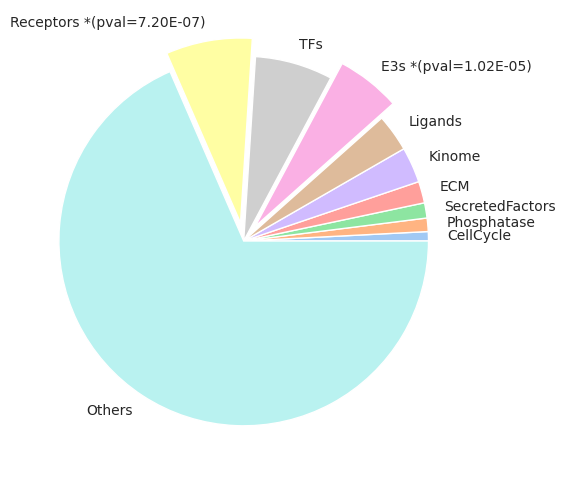

In [43]:
sns.set_style("whitegrid")

with sns.color_palette("pastel"):
    plt.figure(figsize=(6,6))
    plt.pie(
        not_human_but_xenopus_found_gene_set_['intersect'],
        labels=not_human_but_xenopus_found_gene_set_['label'],
        explode=not_human_but_xenopus_found_gene_set_['explode']
    ) #, autopct='%1.1f%%')

#### xenopus_and_human_found_gene_set

In [44]:
xenopus_and_human_found_set = set(xenopus_and_human_found.human_uniprot_id)
xenopus_and_human_found_gene_set = run_fischer_exact_test(
    xenopus_and_human_found_set,
    common_proteins_uniprot_ids,
    all_gene_sets_short,
    gene_set_col="beautiful_name",
    alternative="greater"
)

In [45]:
xenopus_and_human_found_gene_set.sort_values("pval").head(10)

,statistic,pval,table,intersect,label,explode,gene_set
48,16.210648,5.000879e-14,99/9523 vs 3/4678,99,Spliceosome *(pval=5.00E-14),0.1,Spliceosome
32,3.808862,5.170041e-12,170/9452 vs 22/4659,170,Oxidative Phosphorylation *(pval=5.17E-12),0.1,Oxidative Phosphorylation
29,3.642477,1.455120e-11,170/9452 vs 23/4658,170,Mitotic spindle *(pval=1.46E-11),0.1,Mitotic spindle
10,4.273667,5.182149e-11,139/9483 vs 16/4665,139,Endocytosis *(pval=5.18E-11),0.1,Endocytosis
0,16.404657,7.287756e-10,67/9555 vs 2/4679,67,Amino Acid Metabolism *(pval=7.29E-10),0.1,Amino Acid Metabolism
30,inf,5.242347e-09,48/9574 vs 0/4681,48,Nucleolus *(pval=5.24E-09),0.1,Nucleolus
19,1.895388,7.137143e-09,356/9266 vs 93/4588,356,Kinome *(pval=7.14E-09),0.1,Kinome
46,8.691943,8.767472e-09,71/9551 vs 4/4677,71,Ribosome *(pval=8.77E-09),0.1,Ribosome
52,2.949324,1.797548e-08,150/9472 vs 25/4656,150,Translation *(pval=1.80E-08),0.1,Translation
13,inf,1.264679e-07,40/9582 vs 0/4681,40,Fatty Acid Metabolism *(pval=1.26E-07),0.1,Fatty Acid Metabolism


In [46]:
min_intersect = 60
xenopus_and_human_found_gene_set_ = xenopus_and_human_found_gene_set.loc[xenopus_and_human_found_gene_set.intersect >= min_intersect, :]

In [47]:
xenopus_and_human_found_gene_set_ = pd.concat([xenopus_and_human_found_gene_set_,
           pd.DataFrame(
    {
        "explode": 0,
        "label": "Others",
         "intersect": xenopus_and_human_found.shape[0] - xenopus_and_human_found_gene_set_.intersect.sum()
    }, index=["Others"]
           )]
)
xenopus_and_human_found_gene_set_ = xenopus_and_human_found_gene_set_.sort_values("intersect")

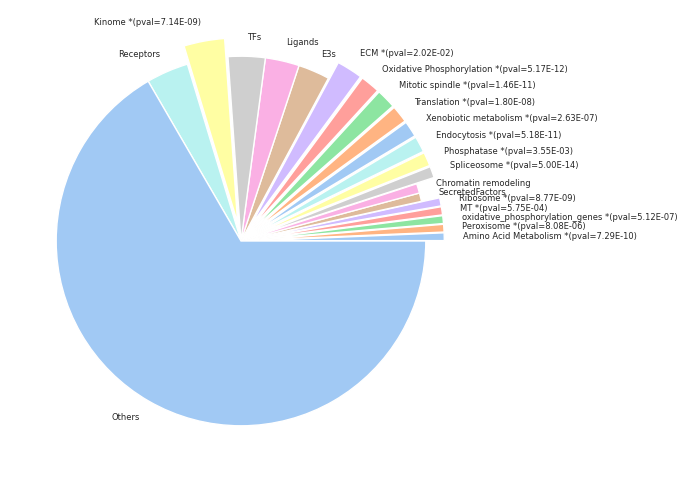

In [48]:
sns.set_style("whitegrid")

with sns.color_palette("pastel"):
    plt.figure(figsize=(6,6))
    plt.pie(
        xenopus_and_human_found_gene_set_['intersect'],
        labels=xenopus_and_human_found_gene_set_['label'],
        explode=xenopus_and_human_found_gene_set_['explode'],
        textprops={'fontsize': 6}
    ) #, autopct='%1.1f%%')

#### not_xenopus_but_human_found_set

In [49]:
not_xenopus_but_human_found_set = set(not_xenopus_but_human_found.xenopus_uniprot_id)
not_xenopus_but_human_found_gene_set = run_fischer_exact_test(
    not_xenopus_but_human_found_set,
    common_proteins_uniprot_ids,
    all_gene_sets_short,
    gene_set_col="beautiful_name",
    alternative="greater"
)

In [50]:
not_xenopus_but_human_found_gene_set.loc[not_xenopus_but_human_found_gene_set.pval < 0.05,:].sort_values("pval")

,statistic,pval,table,intersect,label,explode,gene_set
50,3.814452,1.089074e-32,141/582 vs 811/12769,141,TFs *(pval=1.09E-32),0.1,TFs
47,2.808602,1.302057e-05,26/697 vs 178/13402,26,SecretedFactors *(pval=1.30E-05),0.1,SecretedFactors
3,2.674337,5.120533e-03,11/712 vs 78/13502,11,CellCycle *(pval=5.12E-03),0.1,CellCycle
20,1.484823,1.873366e-02,37/686 vs 476/13104,37,Ligands *(pval=1.87E-02),0.1,Ligands
51,3.771905,3.071399e-02,4/719 vs 20/13560,4,Transcription (nuclear) *(pval=3.07E-02),0.1,Transcription (nuclear)


In [51]:
min_intersect = 10
not_xenopus_but_human_found_gene_set_ = not_xenopus_but_human_found_gene_set.loc[not_xenopus_but_human_found_gene_set.intersect >= min_intersect, :]

In [52]:
not_xenopus_but_human_found_gene_set_ = pd.concat([not_xenopus_but_human_found_gene_set_,
           pd.DataFrame(
    {
        "explode": 0,
        "label": "Others",
         "intersect": not_xenopus_but_human_found.shape[0] - not_xenopus_but_human_found_gene_set_.intersect.sum()
    }, index=["Others"]
           )]
)
not_xenopus_but_human_found_gene_set_ = not_xenopus_but_human_found_gene_set_.sort_values("intersect")

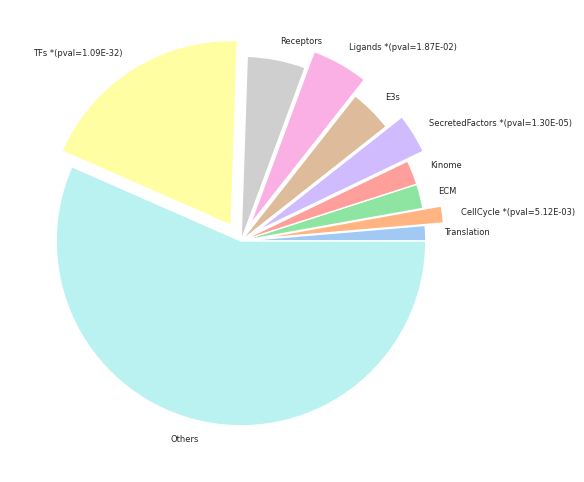

In [53]:
sns.set_style("whitegrid")

with sns.color_palette("pastel"):
    plt.figure(figsize=(6,6))
    plt.pie(
        not_xenopus_but_human_found_gene_set_['intersect'],
        labels=not_xenopus_but_human_found_gene_set_['label'],
        explode=not_xenopus_but_human_found_gene_set_['explode'],
        textprops={'fontsize': 6}
    ) #, autopct='%1.1f%%')

#### not_xenopus_not_human_found_set

In [54]:
not_xenopus_not_human_found_set = set(not_xenopus_not_human_found.xenopus_uniprot_id)
not_xenopus_not_human_found_gene_set = run_fischer_exact_test(
    not_xenopus_not_human_found_set,
    common_proteins_uniprot_ids,
    all_gene_sets_short,
    gene_set_col="beautiful_name",
    alternative="greater"
)

In [55]:
not_xenopus_not_human_found_gene_set.loc[not_xenopus_not_human_found_gene_set.pval < 0.05,:].sort_values("pval")

,statistic,pval,table,intersect,label,explode,gene_set
50,5.418000,1.720195e-104,368/1391 vs 584/11960,368,TFs *(pval=1.72E-104),0.1,TFs
47,4.874662,1.578927e-23,81/1678 vs 123/12421,81,SecretedFactors *(pval=1.58E-23),0.1,SecretedFactors
20,2.316423,1.775052e-13,122/1637 vs 391/12153,122,Ligands *(pval=1.78E-13),0.1,Ligands
44,1.477156,2.940664e-04,110/1649 vs 542/12002,110,Receptors *(pval=2.94E-04),0.1,Receptors


### organ specific

In [28]:
xenopus_found_gene_ids = set(prots_xen.gene_id)

In [57]:
pure_not_human_but_xenopus_found_set = set(pure_not_human_but_xenopus_found.xenopus_gene_id)
not_human_but_xenopus_found_organ_specific = run_fischer_exact_test(
    pure_not_human_but_xenopus_found_set,
    xenopus_found_gene_ids,
    chi_square_os_z,
    alternative="greater",
    gene_id="xenopus_gene_id"
)

In [58]:
not_human_but_xenopus_found_organ_specific.loc[not_human_but_xenopus_found_organ_specific.pval < 0.05,:]

,statistic,pval,table,intersect,label,explode,gene_set
0,2.710047,5.631974e-03,12/1948 vs 29/12758,12,PNS *(pval=5.63E-03),0.1,PNS
14,4.356169,3.363593e-02,4/1956 vs 6/12781,4,bone_marrow *(pval=3.36E-02),0.1,bone_marrow
18,4.356169,3.363593e-02,4/1956 vs 6/12781,4,brain *(pval=3.36E-02),0.1,brain
22,3.767524,2.549702e-07,28/1932 vs 49/12738,28,brain_spinal_cord *(pval=2.55E-07),0.1,brain_spinal_cord
24,1.851595,1.506395e-08,124/1836 vs 450/12337,124,brain_spinal_cord_telencephalon *(pval=1.51E-08),0.1,brain_spinal_cord_telencephalon
27,3.964297,9.151004e-09,33/1927 vs 55/12732,33,brain_telencephalon *(pval=9.15E-09),0.1,brain_telencephalon
32,3.267775,3.924994e-02,5/1955 vs 10/12777,5,gall_bladder_intestine_kidney *(pval=3.92E-02),0.1,gall_bladder_intestine_kidney
43,2.477196,4.512122e-04,23/1937 vs 61/12726,23,kidney *(pval=4.51E-04),0.1,kidney
44,3.815711,8.495138e-03,7/1953 vs 12/12775,7,kidney_larynx *(pval=8.50E-03),0.1,kidney_larynx
47,5.493971,5.816122e-09,25/1935 vs 30/12757,25,kidney_oviduct *(pval=5.82E-09),0.1,kidney_oviduct


In [60]:
xenopus_and_human_found_set = set(xenopus_and_human_found.xenopus_gene_id)
xenopus_and_human_found_organ_specific = run_fischer_exact_test(
    xenopus_and_human_found_set,
    xenopus_found_gene_ids,
    chi_square_os_z,
    alternative="greater",
    gene_id="xenopus_gene_id"
)

In [61]:
xenopus_and_human_found_organ_specific.loc[xenopus_and_human_found_organ_specific.pval < 0.05,:]

,statistic,pval,table,intersect,label,explode,gene_set
2,3.719024,1.275226e-03,39/9956 vs 5/4747,39,PNS_brain_lens_spinal_cord_telencephalon_whole...,0.1,PNS_brain_lens_spinal_cord_telencephalon_whole...
4,2.258929,5.098328e-05,118/9877 vs 25/4727,118,PNS_brain_spinal_cord_telencephalon *(pval=5.1...,0.1,PNS_brain_spinal_cord_telencephalon
20,inf,6.352368e-03,13/9982 vs 0/4752,13,brain_kidney_spinal_cord_telencephalon *(pval=...,0.1,brain_kidney_spinal_cord_telencephalon
21,inf,2.042494e-02,10/9985 vs 0/4752,10,brain_oviduct_spinal_cord_telencephalon *(pval...,0.1,brain_oviduct_spinal_cord_telencephalon
25,4.649759,4.218737e-04,39/9956 vs 4/4748,39,brain_spinal_cord_telencephalon_testes *(pval=...,0.1,brain_spinal_cord_telencephalon_testes
26,1.857553,4.869656e-02,39/9956 vs 10/4742,39,brain_spinal_cord_telencephalon_whole_eye *(pv...,0.1,brain_spinal_cord_telencephalon_whole_eye
35,2.518650,1.197770e-02,37/9958 vs 7/4745,37,heart_vent *(pval=1.20E-02),0.1,heart_vent
51,9.782499,1.203212e-05,41/9954 vs 2/4750,41,lens_pancreas *(pval=1.20E-05),0.1,lens_pancreas
52,8.094508,8.675676e-03,17/9978 vs 1/4751,17,lens_testes *(pval=8.68E-03),0.1,lens_testes
74,2.763805,9.695799e-178,6435/3560 vs 1879/2873,6435,unspecific *(pval=9.70E-178),0.1,unspecific


### cytoplasm/nucleus?

## 4. organ-specific

### gene sets

In [24]:
import decoupler as dc

#### organs and cell-types marker genes

In [25]:
markers = dc.get_resource('PanglaoDB')
idx = markers.genesymbol.isin(uni_human_prots[1])
markers.loc[idx, "uniprot_id"] = uni_human_prots.set_index(1).loc[markers.loc[idx, "genesymbol"], "uniprot_id"].values
markers = markers.loc[~markers.uniprot_id.isna(),:].copy()
markers

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness,uniprot_id
0,CTRB1,False,Enterocytes,Endoderm,True,0.0,0.00439422,True,0.00331126,0.0204803,9606,GI tract,0.017,P17538
1,CTRB1,True,Acinar cells,Endoderm,True,1.0,0.000628931,True,0.957143,0.0159201,9606,Pancreas,0.017,P17538
2,KLK1,True,Endothelial cells,Mesoderm,True,0.0,0.00841969,True,0.0,0.0149153,9606,Vasculature,0.013,P06870
3,KLK1,False,Goblet cells,Endoderm,True,0.588235,0.00503937,True,0.903226,0.0124084,9606,GI tract,0.013,P06870
4,KLK1,False,Epithelial cells,Mesoderm,True,0.0,0.00823306,True,0.225806,0.0137585,9606,Epithelium,0.013,P06870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8456,SLC14A1,True,Urothelial cells,Mesoderm,True,0.0,0.0181704,True,0.0,0.0,9606,Urinary bladder,0.008,Q13336
8457,UPK3A,True,Urothelial cells,Mesoderm,True,0.0,0.0,True,0.0,0.0,9606,Urinary bladder,0.0,O75631
8458,UPK1A,True,Urothelial cells,Mesoderm,True,0.0,0.0,True,0.0,0.0,9606,Urinary bladder,0.0,O00322
8459,UPK2,True,Urothelial cells,Mesoderm,True,0.0,0.0,True,0.0,0.0,9606,Urinary bladder,0.0,O00526


In [31]:
xenopus_found_gene_ids = set(prots_xen.uniprot_id)

##### organs (not resultative)

In [60]:
organ_results = pd.DataFrame()
# pval_threshold = 0.01

for organ, organ_stats in tqdm.tqdm(chi_square_os_z.groupby("gene_set")):
    organs = organ.split(".")
    if len(organs) > 1:
        continue
    organ_genes = set(organ_stats.xenopus_uniprot_id)
    organ_genes_organ_specific = run_fischer_exact_test(
        organ_genes,
        xenopus_found_gene_ids,
        markers,
        alternative="greater",
        min_set_size=5,
        pval_thresh=0.05,
        gene_set_col="organ",
        gene_id="uniprot_id"
    )
    organ_genes_organ_specific["organ"] = organ
    
    organ_results = pd.concat([organ_results, organ_genes_organ_specific], axis=0)

100%|██████████| 2343/2343 [00:01<00:00, 2097.62it/s]


In [62]:
pval_threshold = 0.05
organ_results_ = organ_results.loc[organ_results.pval < pval_threshold, :]
organ_results_

,statistic,pval,table,intersect,label,explode,gene_set,organ
3,2.523247,4.463522e-02,6/34 vs 811/11596,6,Brain *(pval=4.46E-02),0.1,Brain,PNS
8,4.975810,1.140999e-02,4/36 vs 271/12136,4,GI tract *(pval=1.14E-02),0.1,GI tract,PNS
13,7.045195,3.655405e-02,2/38 vs 92/12315,2,Lungs *(pval=3.66E-02),0.1,Lungs,PNS
26,52.995726,2.228498e-02,1/39 vs 6/12401,1,Urinary bladder *(pval=2.23E-02),0.1,Urinary bladder,PNS
1,6.407285,1.404202e-02,3/38 vs 151/12255,3,Blood *(pval=1.40E-02),0.1,Blood,bone
...,...,...,...,...,...,...,...,...
10,3.945870,5.551271e-04,10/57 vs 527/11853,10,Immune system *(pval=5.55E-04),0.1,Immune system,urinary_bladder
13,6.330185,1.410422e-02,3/64 vs 91/12289,3,Lungs *(pval=1.41E-02),0.1,Lungs,urinary_bladder
26,31.247475,3.708552e-02,1/66 vs 6/12374,1,Urinary bladder *(pval=3.71E-02),0.1,Urinary bladder,urinary_bladder
3,2.184490,3.289553e-02,9/59 vs 808/11571,9,Brain *(pval=3.29E-02),0.1,Brain,whole_eye


In [63]:
organ_results_table = organ_results_.pivot(index = 'gene_set', columns = 'organ')['pval'].fillna(1)

In [64]:
organ_results.sort_values("pval")

,statistic,pval,table,intersect,label,explode,gene_set,organ
10,15.466867,7.441413e-28,39/60 vs 498/11850,39,Immune system *(pval=7.44E-28),0.1,Immune system,spleen
9,52.000000,9.495552e-15,11/33 vs 79/12324,11,Heart *(pval=9.50E-15),0.1,Heart,heart_vent
11,13.063582,4.814350e-14,19/61 vs 288/12079,19,Kidney *(pval=4.81E-14),0.1,Kidney,kidney
17,13.360440,9.194845e-14,18/91 vs 180/12158,18,Pancreas *(pval=9.19E-14),0.1,Pancreas,pancreas
27,18.725038,1.753727e-09,10/30 vs 217/12190,10,Vasculature *(pval=1.75E-09),0.1,Vasculature,lungs
...,...,...,...,...,...,...,...,...
11,0.000000,1.000000e+00,0/23 vs 307/12117,0,Kidney,0.0,Kidney,lens
12,0.000000,1.000000e+00,0/23 vs 198/12226,0,Liver,0.0,Liver,lens
13,0.000000,1.000000e+00,0/23 vs 94/12330,0,Lungs,0.0,Lungs,lens
15,0.000000,1.000000e+00,0/23 vs 98/12326,0,Olfactory system,0.0,Olfactory system,lens


Text(255.8522727272727, 0.5, 'pval')

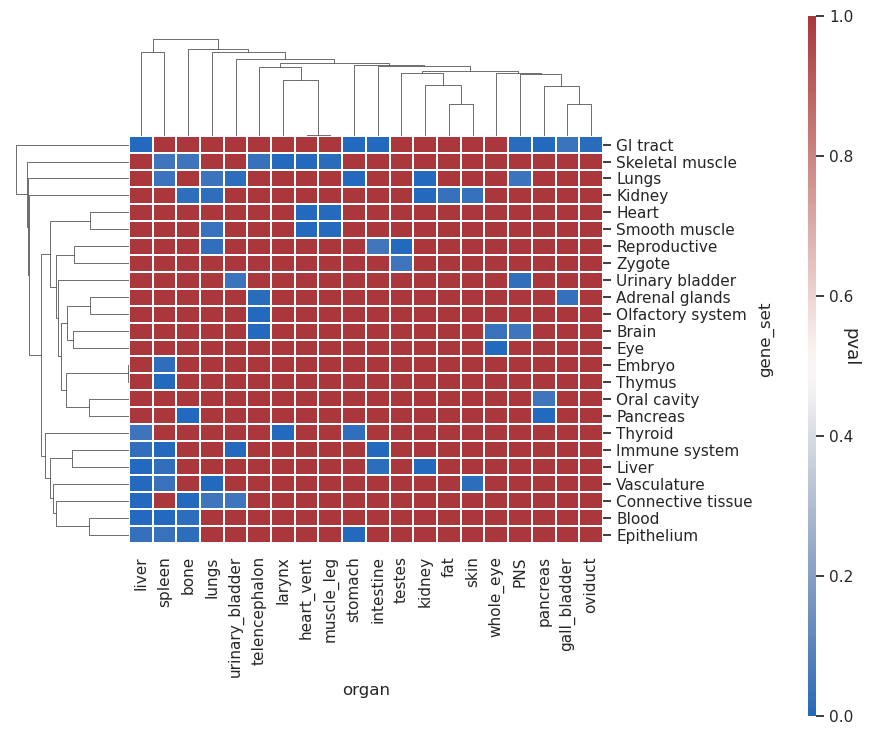

In [65]:
sns.set(font_scale=1)
cl = sns.clustermap(
    organ_results_table,
    cmap="vlag",
    metric="euclidean",
    xticklabels=True,
    figsize=(8, 7),
    linewidths=.003,
    cbar_pos=(1.02, 0, 0.01, 1),
    cbar_kws=dict(label="female/male"),
    # vmin=-3,
    # vmax=3
)
_ = plt.setp(cl.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)
cl.cax.set_ylabel("pval", rotation=270, horizontalalignment="right", size=13)

##### cell-types

In [75]:
cell_type_results = pd.DataFrame()
# pval_threshold = 0.05

for organ, organ_stats in tqdm.tqdm(chi_square_os_z.groupby("gene_set")):
    organs = organ.split(".")
    if len(organs) > 1:
        continue
    organ_genes = set(organ_stats.xenopus_uniprot_id)
    organ_genes_cell_type_specific = run_fischer_exact_test(
        organ_genes,
        xenopus_found_gene_ids,
        markers,
        alternative="greater",
        min_set_size=5,
        pval_thresh=0.05,
        gene_set_col="cell_type",
        gene_id="uniprot_id"
    )
    # organ_genes_cell_type_specific = organ_genes_organ_specific.loc[organ_genes_cell_type_specific.pval < pval_threshold, :]
    organ_genes_cell_type_specific["organ"] = organ
    
    cell_type_results = pd.concat([cell_type_results, organ_genes_cell_type_specific], axis=0)

100%|██████████| 2343/2343 [00:05<00:00, 465.42it/s] 


In [76]:
cell_type_results

,statistic,pval,table,intersect,label,explode,gene_set,organ
0,0.0,1.0,0/40 vs 29/12378,0,Acinar cells,0.0,Acinar cells,PNS
1,0.0,1.0,0/40 vs 10/12397,0,Adipocyte progenitor cells,0.0,Adipocyte progenitor cells,PNS
2,0.0,1.0,0/40 vs 82/12325,0,Adipocytes,0.0,Adipocytes,PNS
3,0.0,1.0,0/40 vs 6/12401,0,Adrenergic neurons,0.0,Adrenergic neurons,PNS
4,0.0,1.0,0/40 vs 18/12389,0,Airway goblet cells,0.0,Airway goblet cells,PNS
...,...,...,...,...,...,...,...,...
156,0.0,1.0,0/68 vs 32/12347,0,Trigeminal neurons,0.0,Trigeminal neurons,whole_eye
157,0.0,1.0,0/68 vs 15/12364,0,Trophoblast cells,0.0,Trophoblast cells,whole_eye
158,0.0,1.0,0/68 vs 15/12364,0,Tuft cells,0.0,Tuft cells,whole_eye
159,0.0,1.0,0/68 vs 5/12374,0,Undefined placental cells,0.0,Undefined placental cells,whole_eye


In [78]:
pval_threshold = 0.05
cell_type_results_ = cell_type_results.loc[cell_type_results.pval < pval_threshold, :]
cell_type_results_

,statistic,pval,table,intersect,label,explode,gene_set,organ
36,28.895105,3.790561e-02,1/39 vs 11/12396,1,Enteric glia cells *(pval=3.79E-02),0.1,Enteric glia cells,PNS
38,63.600000,1.913132e-02,1/39 vs 5/12402,1,Enterochromaffin cells *(pval=1.91E-02),0.1,Enterochromaffin cells,PNS
41,26.485043,4.100040e-02,1/39 vs 12/12395,1,Eosinophils *(pval=4.10E-02),0.1,Eosinophils,PNS
82,35.321937,3.168678e-02,1/39 vs 9/12398,1,Merkel cells *(pval=3.17E-02),0.1,Merkel cells,PNS
100,18.604511,6.246465e-03,2/38 vs 35/12372,2,Neutrophils *(pval=6.25E-03),0.1,Neutrophils,PNS
...,...,...,...,...,...,...,...,...
117,37.339718,5.107876e-08,6/62 vs 32/12347,6,Photoreceptor cells *(pval=5.11E-08),0.1,Photoreceptor cells,whole_eye
118,133.010753,1.021810e-10,6/62 vs 9/12370,6,Pinealocytes *(pval=1.02E-10),0.1,Pinealocytes,whole_eye
132,30.778607,3.762998e-02,1/67 vs 6/12373,1,Reticulocytes *(pval=3.76E-02),0.1,Reticulocytes,whole_eye
134,74.993939,6.067691e-04,2/66 vs 5/12374,2,Retinal progenitor cells *(pval=6.07E-04),0.1,Retinal progenitor cells,whole_eye


In [81]:
cell_type_results_table = cell_type_results_.pivot(index = 'gene_set', columns = 'organ')['pval'].fillna(0.05)

In [80]:
cell_type_results.sort_values("pval")

,statistic,pval,table,intersect,label,explode,gene_set,organ
0,140.471125,3.525400e-24,15/94 vs 14/12324,15,Acinar cells *(pval=3.53E-24),0.1,Acinar cells,pancreas
146,65.368700,7.363458e-17,12/87 vs 26/12322,12,T cells *(pval=7.36E-17),0.1,T cells,spleen
18,60.465686,2.118776e-15,11/33 vs 68/12335,11,Cardiomyocytes *(pval=2.12E-15),0.1,Cardiomyocytes,heart_vent
150,60.210064,5.063542e-14,10/89 vs 23/12325,10,T memory cells *(pval=5.06E-14),0.1,T memory cells,spleen
33,36.592262,3.724924e-12,10/30 vs 112/12295,10,Endothelial cells *(pval=3.72E-12),0.1,Endothelial cells,lungs
...,...,...,...,...,...,...,...,...
56,0.000000,1.000000e+00,0/8 vs 21/12418,0,Glomus cells,0.0,Glomus cells,larynx
57,0.000000,1.000000e+00,0/8 vs 8/12431,0,Glutaminergic neurons,0.0,Glutaminergic neurons,larynx
58,0.000000,1.000000e+00,0/8 vs 15/12424,0,Goblet cells,0.0,Goblet cells,larynx
60,0.000000,1.000000e+00,0/8 vs 61/12378,0,Hematopoietic stem cells,0.0,Hematopoietic stem cells,larynx


In [96]:
from IPython.display import display

with pd.option_context('display.max_rows', None):
    display(markers.value_counts(["organ", "cell_type"]).sort_index())

organ               cell_type                                   
Adrenal glands      Chromaffin cells                                 25
Blood               Erythroblasts                                    26
                    Erythroid-like and erythroid precursor cells     69
                    Platelets                                       126
                    Reticulocytes                                     8
Bone                Hematopoietic stem cells                         89
                    Osteoblasts                                      62
                    Osteoclast precursor cells                        8
                    Osteoclasts                                      49
                    Osteocytes                                        5
Brain               Adrenergic neurons                                8
                    Anterior pituitary gland cells                   35
                    Astrocytes                                       63

Text(577.6931818181818, 0.5, 'pval')

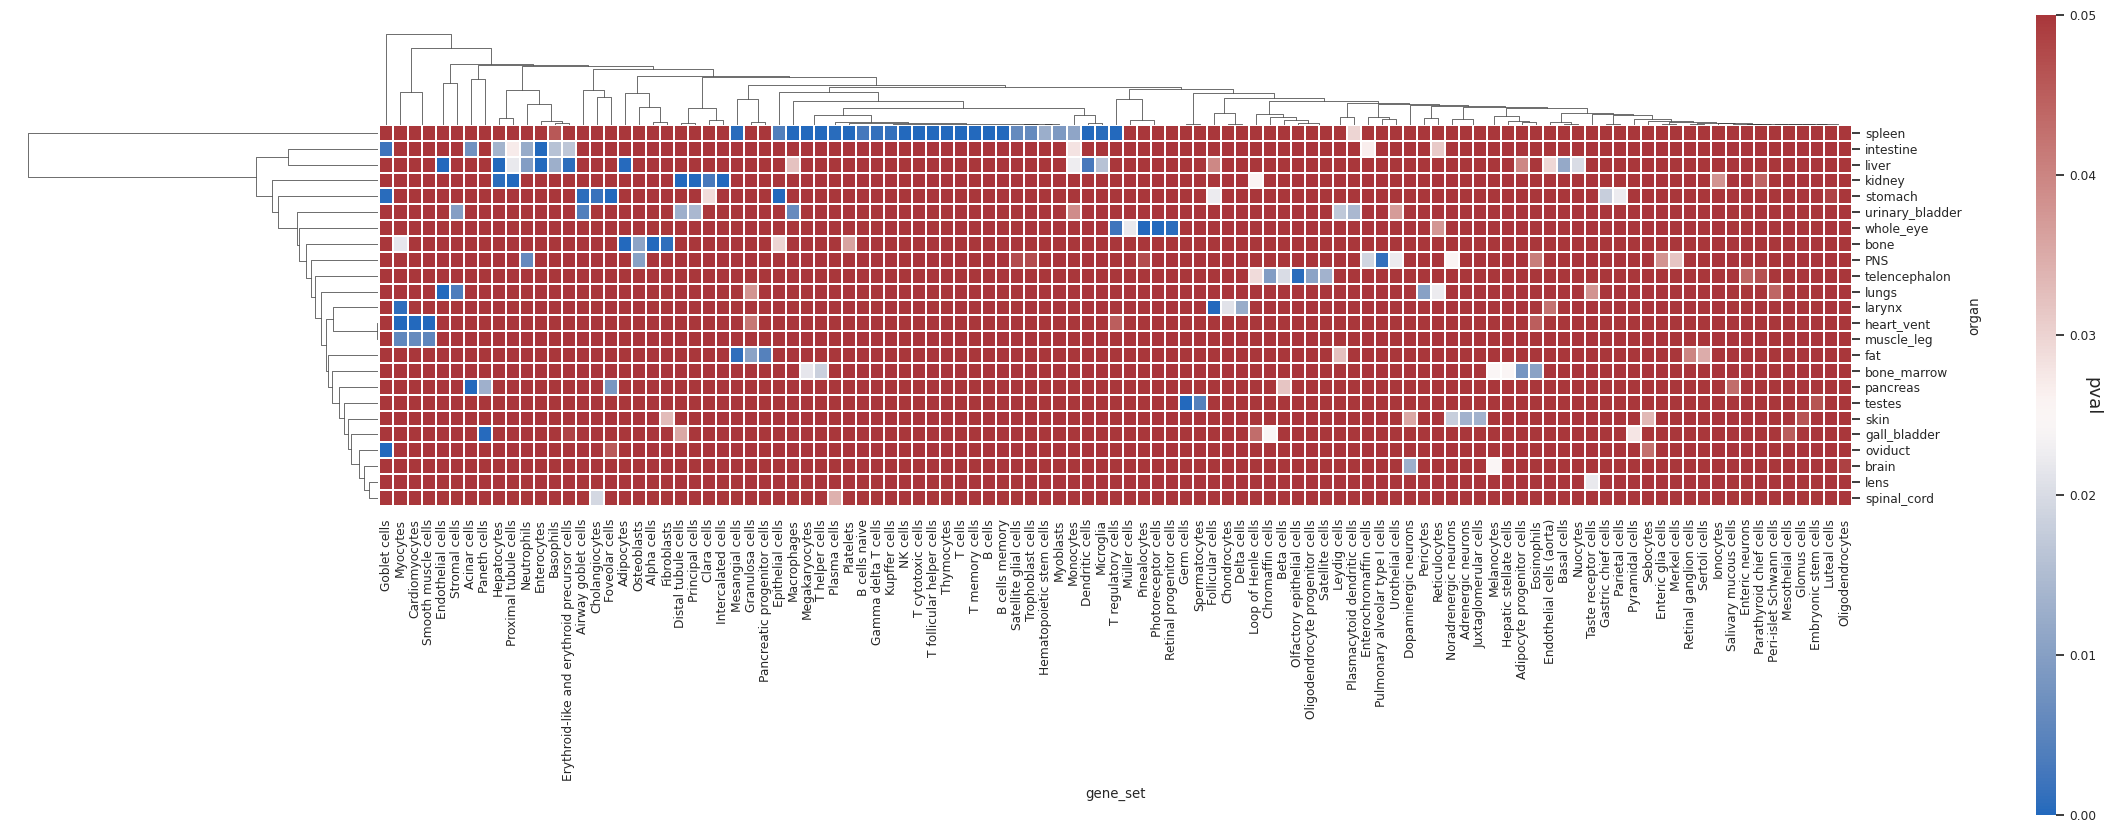

In [93]:
sns.set(font_scale=0.8)
cl = sns.clustermap(
    cell_type_results_table.T,
    cmap="vlag",
    metric="cosine",
    xticklabels=True,
    figsize=(20, 8),
    linewidths=.003,
    cbar_pos=(1.02, 0, 0.01, 1),
    cbar_kws=dict(label="pval"),
    # vmin=-3,
    # vmax=3
)
_ = plt.setp(cl.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)
cl.cax.set_ylabel("pval", rotation=270, horizontalalignment="right", size=13)

In [114]:
# prots_xen_set = set(prots_xen.gene_id)
# prots_xen.shape, len(prots_xen_set)

((14747, 201), 14747)

In [123]:
# min_organ_gene_set = 30
# organ_specific_gene_sets = {}
# pval_thresh = 0.05


# for organs, genes in chi_square_organ_specificity_z.items():
#     if len(genes) < min_organ_gene_set:
#         continue
#     genes_set = set(genes)
#     fischer_result = run_fischer_exact_test(
#         genes_set,
#         prots_xen_set,
#         all_gene_sets,
#         alternative="greater"
#     )
#     signif_num = (fischer_result.pval < pval_thresh).sum()
#     if signif_num:
#         organ_specific_gene_sets[organs] = fischer_result
#         print(organs, signif_num)

('oviduct',) 3
('intestine', 'kidney', 'liver') 3
('PNS',) 2
('lens', 'pancreas') 1
('spleen',) 4
('lungs',) 2
('skin',) 3
('brain', 'spinal_cord', 'telencephalon') 3
('unspecific',) 30
('liver', 'spleen') 2
('skin', 'thymus') 3
('bone',) 4
('pancreas',) 2
('PNS', 'brain', 'spinal_cord', 'telencephalon') 2
('skin', 'whole_eye') 5
('brain', 'spinal_cord') 1
('urinary_bladder',) 3
('kidney',) 1
('stomach',) 5
('heart_vent',) 1
('testes',) 5
('spleen', 'testes') 2
('telencephalon',) 2
('kidney', 'liver') 4
('brain', 'telencephalon') 1
('brain', 'spinal_cord', 'telencephalon', 'testes') 2
('bone', 'bone_marrow', 'liver', 'spleen') 2
('whole_eye',) 1
('liver',) 2


In [ ]:
# from IPython.display import display

# for organs, t in organ_specific_gene_sets.items():
#     print(organs)
#     display(t.loc[t.pval < pval_thresh])

# Ranging

In [108]:
import decoupler as dc

In [ ]:
(
    so.Plot(
        data=(
            gsea_results.loc[(gsea_results.pval < 0.05) & (gsea_results.score > 0), :].sort_values("pval", ascending=True).head(20).assign(
                **{"-log10(pval)": lambda x: -np.log10(x["pval"])}
            )
        ),
        x="-log10(pval)",
        y="source",
    ).add(so.Bar())
)

## RNA-prot correlation

### gene sets

In [109]:
rna_prot_gene_cor_coef_df_ = rna_prot_gene_cor_coef_df.loc[rna_prot_gene_cor_coef_df.gene_prot.isin(prots_xen.loc[~prots_xen.uniprot_id.isna(), "gene_id"]),:]
rna_prot_gene_cor_coef_df_

,Spearman_r,gene_prot,gene_rna
0,0.405594,Xetrov107030192m,Xelaev18024843m
1,0.192645,Xetrov107030211m,Xelaev18024857m
2,0.454545,Xetrov107030280m,Xelaev18024866m
3,-0.209790,Xetrov107030287m,Xelaev18024869m
4,0.699301,Xetrov107030338m,Xelaev18024883m
...,...,...,...
14058,0.321678,Xetrov107027943m,Xelaev18024583m
14059,0.706294,Xetrov107027940m,Xelaev18024586m
14060,-0.122592,Xetrov107022569m,Xelaev18024589m
14061,0.392232,Xetrov107027933m,Xelaev18024590m


In [103]:
rna_prot_gene_score = rna_prot_gene_cor_coef_df_.set_index("gene_prot")[["Spearman_r",]].T

scores, norm, pvals = dc.run_gsea(
    rna_prot_gene_score,
    all_gene_sets,
    source="gene_set",
    target="uniprot_id"
)

gsea_results = (
    pd.concat({"score": scores.T, "norm": norm.T, "pval": pvals.T}, axis=1)
    .droplevel(level=1, axis=1)
    .sort_values("pval")
)

In [104]:
gsea_results.loc[gsea_results.pval < 0.05,:].sort_values("score")

,score,norm,pval
source,,,
Ribosome (76),-0.866582,-6.363918,1.966714e-10
Translation (165),-0.257424,-2.722562,6.477782e-03
Ligands (496),0.210790,3.068281,2.152943e-03
E3s (503),0.215846,3.344597,8.240225e-04
GO_PHOSPHATASE (167),0.244064,2.513945,1.193892e-02
Lysosome (79),0.258003,2.050937,4.027309e-02
HALLMARK_XENOBIOTIC_METABOLISM (243),0.275911,3.237937,1.203974e-03
TFs (518),0.281838,4.201377,2.652959e-05
ECM (336),0.282494,4.000014,6.333865e-05


Text(0, 0.5, '')

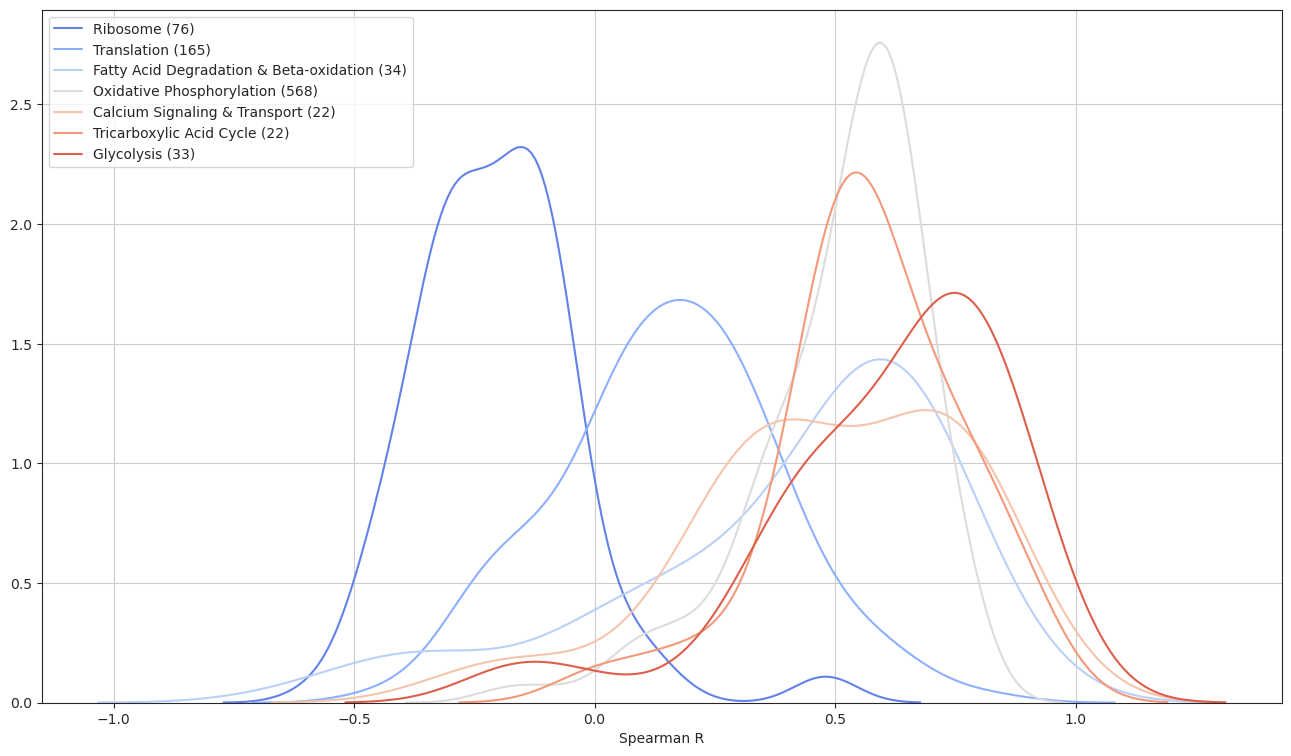

In [112]:
gsea_sub = pd.concat(
    [gsea_results.loc[gsea_results.pval < 0.05,:].sort_values("score").iloc[:2],
     gsea_results.loc[gsea_results.pval < 0.05,:].sort_values("score").iloc[-5:]
    ]
)

with sns.color_palette("coolwarm", gsea_sub.shape[0]):
    
    fig, ax = plt.subplots(figsize=(16,9))
    sns.set_style("ticks")

    for gene_set, stats in gsea_sub.iterrows():

        gene_set_genes = gene_set_col_df.loc[gene_set_col_df.geneset == gene_set, "gene_id"]
        gene_set_r = rna_prot_gene_cor_coef_df_.loc[rna_prot_gene_cor_coef_df_.gene_prot.isin(gene_set_genes), "Spearman_r"]

        sns.kdeplot(gene_set_r, ax=ax, label=gene_set)

    ax.set_xlabel("Spearman r coef")
    plt.grid()
    plt.legend()
    
ax.set_xlabel("Spearman R")
ax.set_ylabel("")

### organ specific

In [18]:
organ_specific_col = []
min_gene_set_size = 15

for organs, organ_genes in chi_square_organ_specificity_z.items():
    if len(organ_genes) < min_gene_set_size:
        continue
        
    for gene in organ_genes:
        organs_ = ".".join(organs)
        organ_specific_col.append({"geneset": organs_, "gene_id": gene})

organ_specific_col_df = pd.DataFrame.from_dict(organ_specific_col)

In [19]:
rna_prot_gene_score = rna_prot_gene_cor_coef_df.set_index("gene_prot")[["Spearman_r",]].T

scores, norm, pvals = dc.run_gsea(
    rna_prot_gene_score,
    organ_specific_col_df,
    source="geneset",
    target="gene_id"
)

gsea_results = (
    pd.concat({"score": scores.T, "norm": norm.T, "pval": pvals.T}, axis=1)
    .droplevel(level=1, axis=1)
    .sort_values("pval")
)

In [20]:
gsea_results.loc[gsea_results.pval < 0.1,:].sort_values("score")

,score,norm,pval
source,,,
lens.pancreas,-0.804895,-4.519273,6.205240e-06
kidney.larynx,-0.620744,-1.810173,7.026892e-02
bone,-0.328559,-1.742753,8.137670e-02
brain.spinal_cord.telencephalon,0.167279,2.480347,1.312544e-02
unspecific,0.175274,10.357486,3.870009e-25
PNS.brain.spinal_cord.telencephalon,0.197938,1.909699,5.617194e-02
testes,0.250761,2.769397,5.616015e-03
kidney.liver,0.306236,2.115780,3.436355e-02
heart_vent,0.347279,1.981101,4.757997e-02


## nuc to cyto

### xenopus vs human

## organ specificity score

In [24]:
chi_square_os_z

,gene_set,xenopus_gene_id,xenopus_uniprot_id,source
0,PNS_bone_bone_marrow_brain_larynx_lens_liver_m...,Xetrov107058441m,P50993,chi_square_organ_specificity_z
1,PNS_bone_bone_marrow_brain_larynx_muscle_leg_s...,Xetrov107057320m,Q15413,chi_square_organ_specificity_z
2,PNS_bone_bone_marrow_brain_larynx_muscle_leg_s...,Xetrov107041238m,Q9HCP6,chi_square_organ_specificity_z
3,PNS_bone_bone_marrow_brain_larynx_muscle_leg_s...,Xetrov107057320m,Q15413,chi_square_organ_specificity_z
4,PNS_bone_bone_marrow_brain_larynx_muscle_leg_s...,Xetrov107041238m,Q9HCP6,chi_square_organ_specificity_z
...,...,...,...,...
15162,whole_eye,Xetrov107019250m,Q9UF11,chi_square_organ_specificity_z
15163,whole_eye,Xetrov107034597m,Q9HBL6,chi_square_organ_specificity_z
15164,whole_eye,Xetrov107036254m,Q6U736,chi_square_organ_specificity_z
15165,whole_eye,Xetrov107039998m,Q9H6R7,chi_square_organ_specificity_z


### gene sets